# Decision Tree Model — Online Shoppers Purchasing Intention Dataset

**Module:** IT2011 – Artificial Intelligence and Machine Learning<br>
**IT25102733 - Fernando W M M P D**<br>
**Task:** Train, tune and evaluate a<br>**Decision Tree** classifier that predicts whether an
online shopping session ends in a purchase (`Revenue = TRUE`).

## About the dataset
- **Source:** UCI Machine Learning Repository — *Online Shoppers Purchasing Intention*
- **Size:** 12,330 sessions × 17 features + 1 target column
- **Target:** `Revenue` (binary) — `TRUE` if the session ended with a purchase (~15.5 % of sessions)
- **Features:** numeric (e.g. `ProductRelated_Duration`, `PageValues`, `BounceRates`) and
  categorical (`Month`, `VisitorType`, `OperatingSystems`, `Browser`, `Region`, `TrafficType`, `Weekend`)

## 1. Import Libraries
Libraries for data handling, visualisation, preprocessing, modeling and evaluation.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay, ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
pd.set_option("display.max_columns", 30)

## 2. Load the Dataset

In [13]:
DATA_PATH = "online+shoppers+purchasing+intention+dataset (1)/online_shoppers_intention.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape (rows, columns):", df.shape)
print()
print("Column names and data types:")
print(df.dtypes)
df.head()

Dataset shape (rows, columns): (12330, 18)

Column names and data types:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Exploratory Data Analysis (EDA)

### 3.1 Data quality — missing values & duplicates
The dataset is known to be complete, but we verify rather than assume.

In [14]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

if df.duplicated().sum() > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates dropped -> new shape:", df.shape)

Missing values per column:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

Total missing values: 0
Duplicate rows: 125
Duplicates dropped -> new shape: (12205, 18)


### 3.2 Descriptive statistics & target distribution

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12205.0,2.338878,3.330436,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12205.0,81.646331,177.491845,0.0,0.000000,9.000000,94.700000,3398.750000
Informational,12205.0,0.508726,1.275617,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12205.0,34.825454,141.424807,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12205.0,32.045637,44.593649,0.0,8.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12205.0,1206.982457,1919.601400,0.0,193.000000,608.942857,1477.154762,63973.522230
BounceRates,12205.0,0.020370,0.045255,0.0,0.000000,0.002899,0.016667,0.200000
ExitRates,12205.0,0.041466,0.046163,0.0,0.014231,0.025000,0.048529,0.200000
PageValues,12205.0,5.949574,18.653671,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12205.0,0.061942,0.199666,0.0,0.000000,0.000000,0.000000,1.000000


Counts:
Revenue
False    10297
True      1908
Name: count, dtype: int64

Proportions:
Revenue
False    0.843671
True     0.156329
Name: proportion, dtype: float64


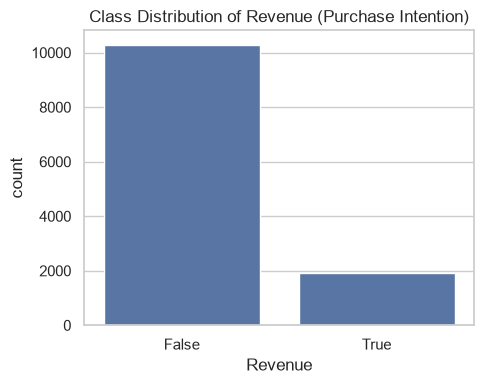

In [4]:
counts = df["Revenue"].value_counts()
props = df["Revenue"].value_counts(normalize=True)
print("Counts:")
print(counts)
print()
print("Proportions:")
print(props)

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="Revenue", data=df, ax=ax)
ax.set_title("Class Distribution of Revenue (Purchase Intention)")
plt.tight_layout()
plt.show()

### 3.3 Distributions of key numeric features

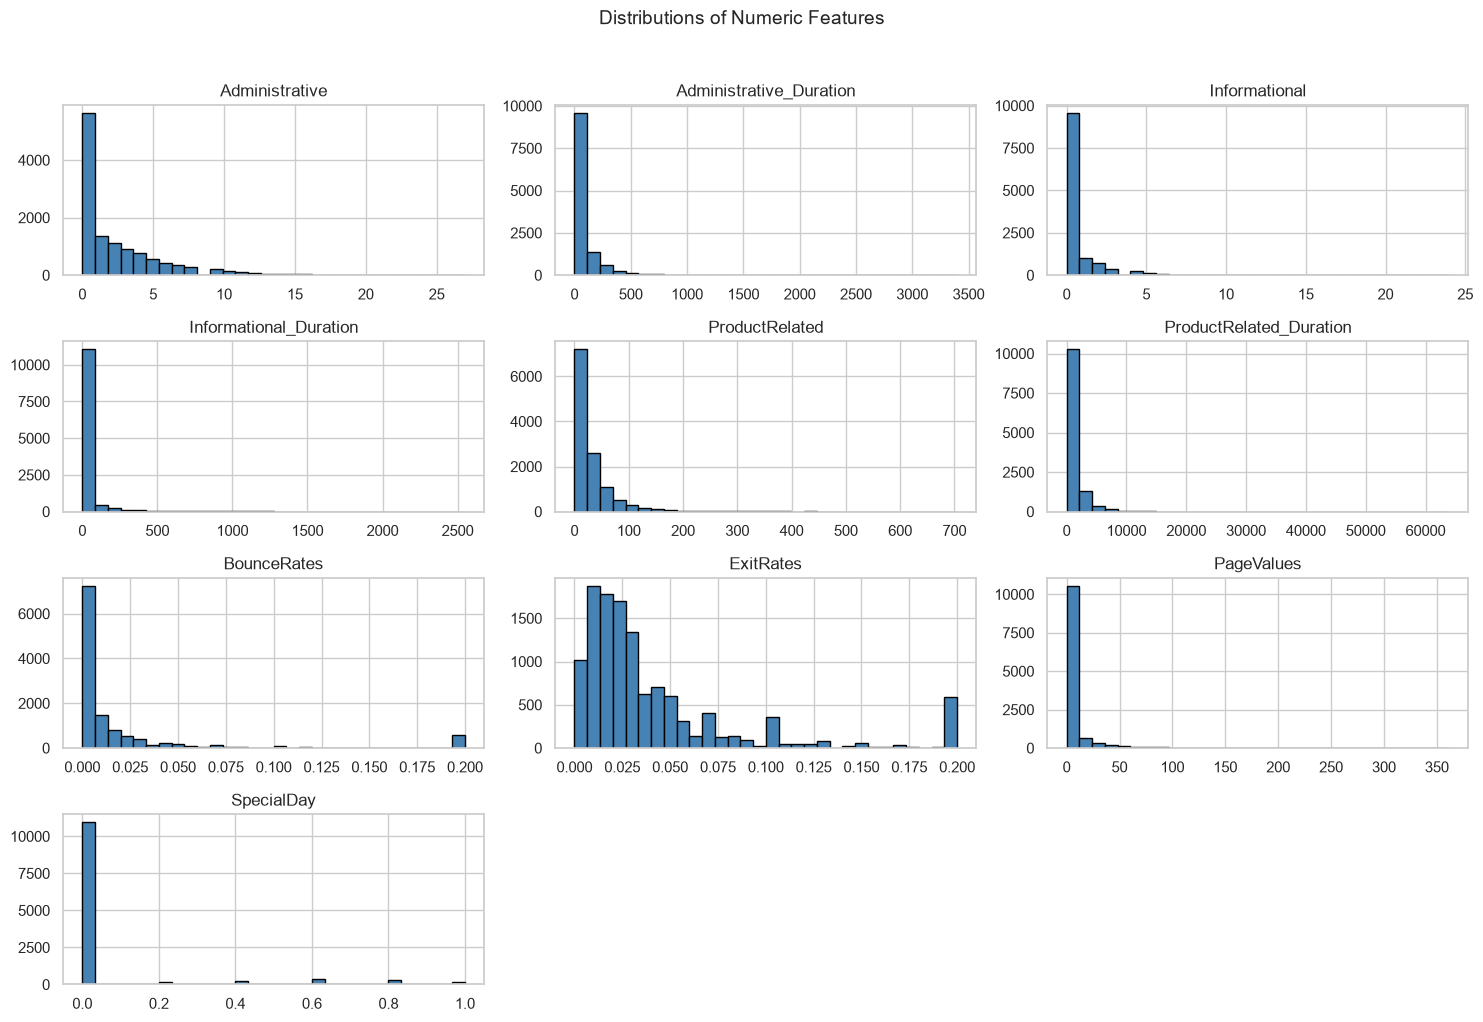

In [16]:
numeric_cols = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay",
]

df[numeric_cols].hist(bins=30, figsize=(15, 10), color="steelblue", edgecolor="black")
plt.suptitle("Distributions of Numeric Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 3.4 Categorical features vs the target

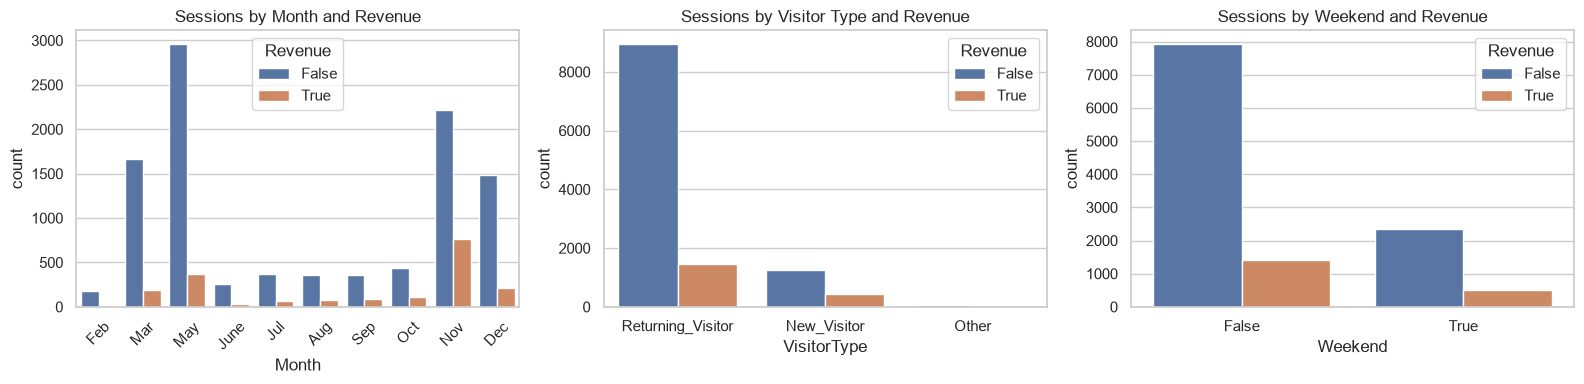

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(x="Month", data=df, hue="Revenue",
              order=["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
              ax=axes[0])
axes[0].set_title("Sessions by Month and Revenue")
axes[0].tick_params(axis="x", rotation=45)

sns.countplot(x="VisitorType", data=df, hue="Revenue", ax=axes[1])
axes[1].set_title("Sessions by Visitor Type and Revenue")

sns.countplot(x="Weekend", data=df, hue="Revenue", ax=axes[2])
axes[2].set_title("Sessions by Weekend and Revenue")

plt.tight_layout()
plt.show()

### 3.5 Correlation heatmap (numeric features + encoded target)

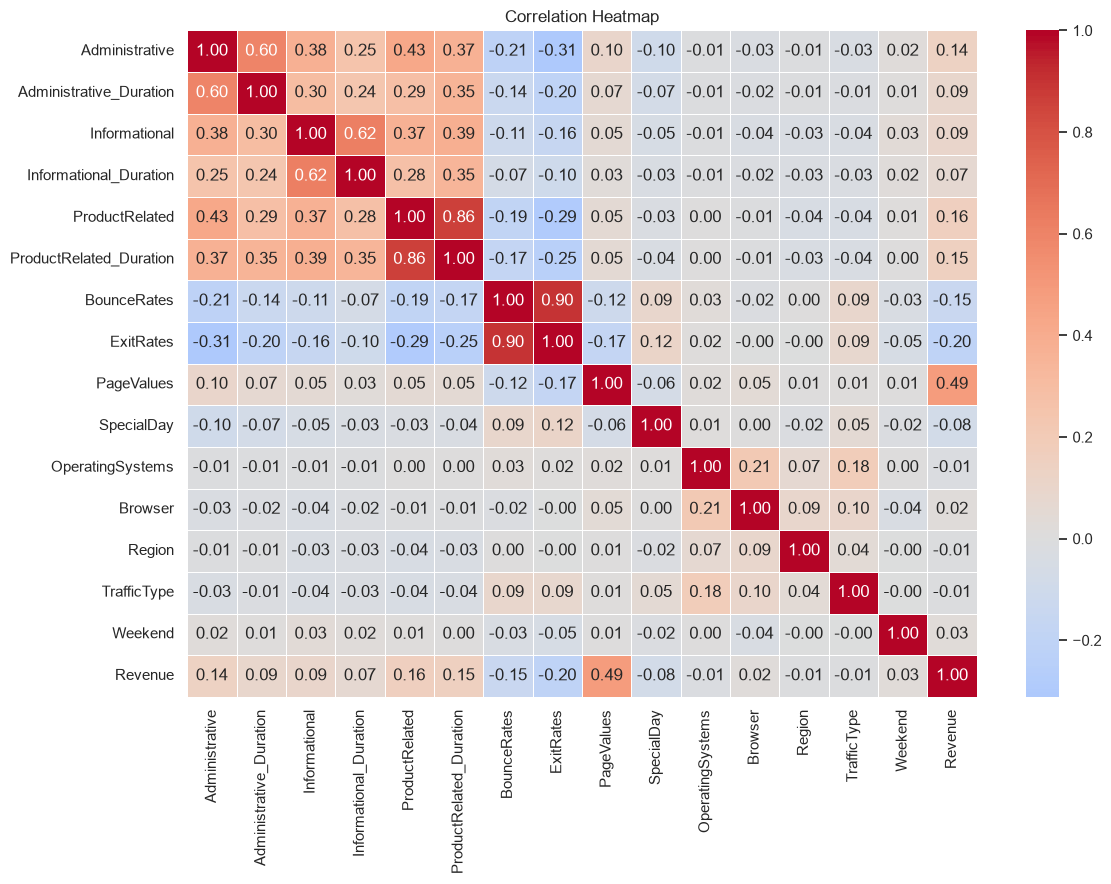

In [18]:
df_corr = df.copy()
df_corr["Revenue"] = df_corr["Revenue"].astype(int)
df_corr["Weekend"] = df_corr["Weekend"].astype(int)

plt.figure(figsize=(12, 9))
sns.heatmap(df_corr.corr(numeric_only=True), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.4)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### 3.6 Key features split by the target

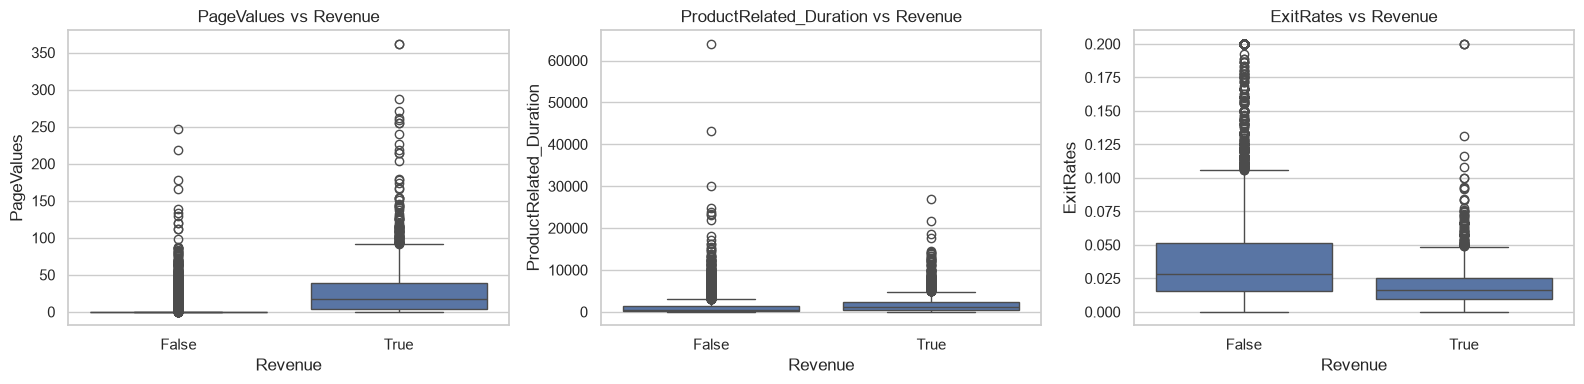

,PageValues,ProductRelated_Duration,ExitRates,BounceRates
Revenue,,,,
False,1.999985,1082.976881,0.045526,0.023197
True,27.264518,1876.209615,0.019555,0.005117


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ["PageValues", "ProductRelated_Duration", "ExitRates"]):
    sns.boxplot(x="Revenue", y=col, data=df, ax=ax)
    ax.set_title(f"{col} vs Revenue")

plt.tight_layout()
plt.show()

df.groupby("Revenue")[["PageValues", "ProductRelated_Duration", "ExitRates", "BounceRates"]].mean()

## 4. Preprocessing

1. **Ordinal-encode** `Month` (Feb = 1 … Dec = 10 — the dataset has no Jan).
2. **Convert booleans** `Weekend` and `Revenue` to 0/1.
3. **One-hot encode** `VisitorType` and the categorical codes `OperatingSystems`,
   `Browser`, `Region`, `TrafficType` (they are IDs, not true quantities).
4. **Scale** numeric features with `StandardScaler` (not required by trees, but kept to
   match the lab sheet pipeline).
5. **Split** 80 % train / 20 % test with `random_state=42`, stratified on the target.

In [20]:
data = df.copy()

month_map = {"Feb": 1, "Mar": 2, "Apr": 3, "May": 4, "June": 5,
             "Jul": 6, "Aug": 7, "Sep": 8, "Oct": 9, "Nov": 10, "Dec": 11}
data["Month"] = data["Month"].map(month_map)
assert data["Month"].notna().all(), "Unmapped month value found!"

data["Weekend"] = data["Weekend"].astype(int)
data["Revenue"] = data["Revenue"].astype(int)
cat_cols = ["VisitorType", "OperatingSystems", "Browser", "Region", "TrafficType"]
data = pd.get_dummies(data, columns=cat_cols, drop_first=False)

print("Shape after encoding:", data.shape)
data.head()

Shape after encoding: (12205, 66)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,Weekend,Revenue,VisitorType_New_Visitor,VisitorType_Other,...,TrafficType_6,TrafficType_7,TrafficType_8,TrafficType_9,TrafficType_10,TrafficType_11,TrafficType_12,TrafficType_13,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,1,0,0,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,1,0,0,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,1,0,0,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,1,0,0,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,1,1,0,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [21]:
X = data.drop(columns=["Revenue"])
y = data["Revenue"]

# Train/test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print()
print("Class ratio in train:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Class ratio in test :", y_test.value_counts(normalize=True).round(3).to_dict())

Training samples: 9764
Testing samples : 2441

Class ratio in train: {0: 0.844, 1: 0.156}
Class ratio in test : {0: 0.844, 1: 0.156}


In [22]:
# Scale numeric columns
num_cols = [c for c in numeric_cols if c in X_train.columns]

scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,Weekend,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor,...,TrafficType_6,TrafficType_7,TrafficType_8,TrafficType_9,TrafficType_10,TrafficType_11,TrafficType_12,TrafficType_13,TrafficType_14,TrafficType_15,TrafficType_16,TrafficType_17,TrafficType_18,TrafficType_19,TrafficType_20
7469,1.689206,0.676238,0.381750,-0.243015,0.220868,-0.080395,-0.448703,-0.800192,1.665596,-0.311837,10,0,False,False,True,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11804,-0.699498,-0.458067,-0.397879,-0.243015,-0.046900,-0.158842,-0.448703,-0.739774,1.495448,-0.311837,11,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3250,-0.699498,-0.458067,-0.397879,-0.243015,-0.426237,-0.408089,-0.448703,-0.287446,-0.315264,3.689185,4,0,False,False,True,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
204,-0.102322,-0.235218,-0.397879,-0.243015,-0.604748,-0.336795,-0.448703,-0.279507,-0.315264,-0.311837,2,1,True,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4392,-0.699498,-0.458067,-0.397879,-0.243015,-0.359295,0.203501,-0.448703,-0.609743,-0.315264,-0.311837,4,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False


## 5. Train the Baseline Decision Tree
`DecisionTreeClassifier` with default settings and `random_state=42` for reproducibility.

In [23]:
model_dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
model_dt.fit(X_train, y_train)

print("Tree depth:", model_dt.get_depth())
print("Number of leaves:", model_dt.get_n_leaves())

y_pred_dt = model_dt.predict(X_test)
y_proba_dt = model_dt.predict_proba(X_test)[:, 1]

Tree depth: 29
Number of leaves: 810


## 6. Evaluate Model Performance

In [24]:
def evaluate(y_true, y_pred, y_proba, label=""):
    print(f"===== {label} =====")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1 score : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC AUC  : {roc_auc_score(y_true, y_proba):.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=["No Purchase", "Purchase"]))


evaluate(y_test, y_pred_dt, y_proba_dt, "Baseline Decision Tree")

===== Baseline Decision Tree =====
Accuracy : 0.8562
Precision: 0.5381
Recall   : 0.5733
F1 score : 0.5551
ROC AUC  : 0.7410

              precision    recall  f1-score   support

 No Purchase       0.92      0.91      0.91      2059
    Purchase       0.54      0.57      0.56       382

    accuracy                           0.86      2441
   macro avg       0.73      0.74      0.73      2441
weighted avg       0.86      0.86      0.86      2441



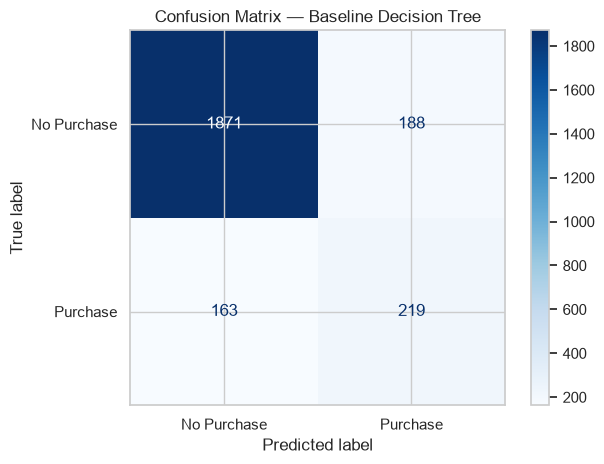

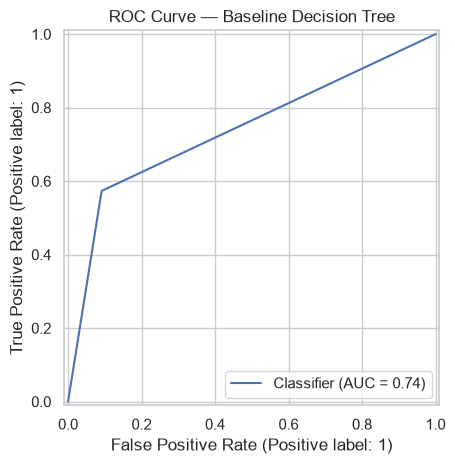

In [25]:
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Purchase", "Purchase"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Baseline Decision Tree")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, y_proba_dt)
plt.title("ROC Curve — Baseline Decision Tree")
plt.tight_layout()
plt.show()

## 7. Visualize the Tree
### 7.1 Tree structure (top 3 levels for readability)

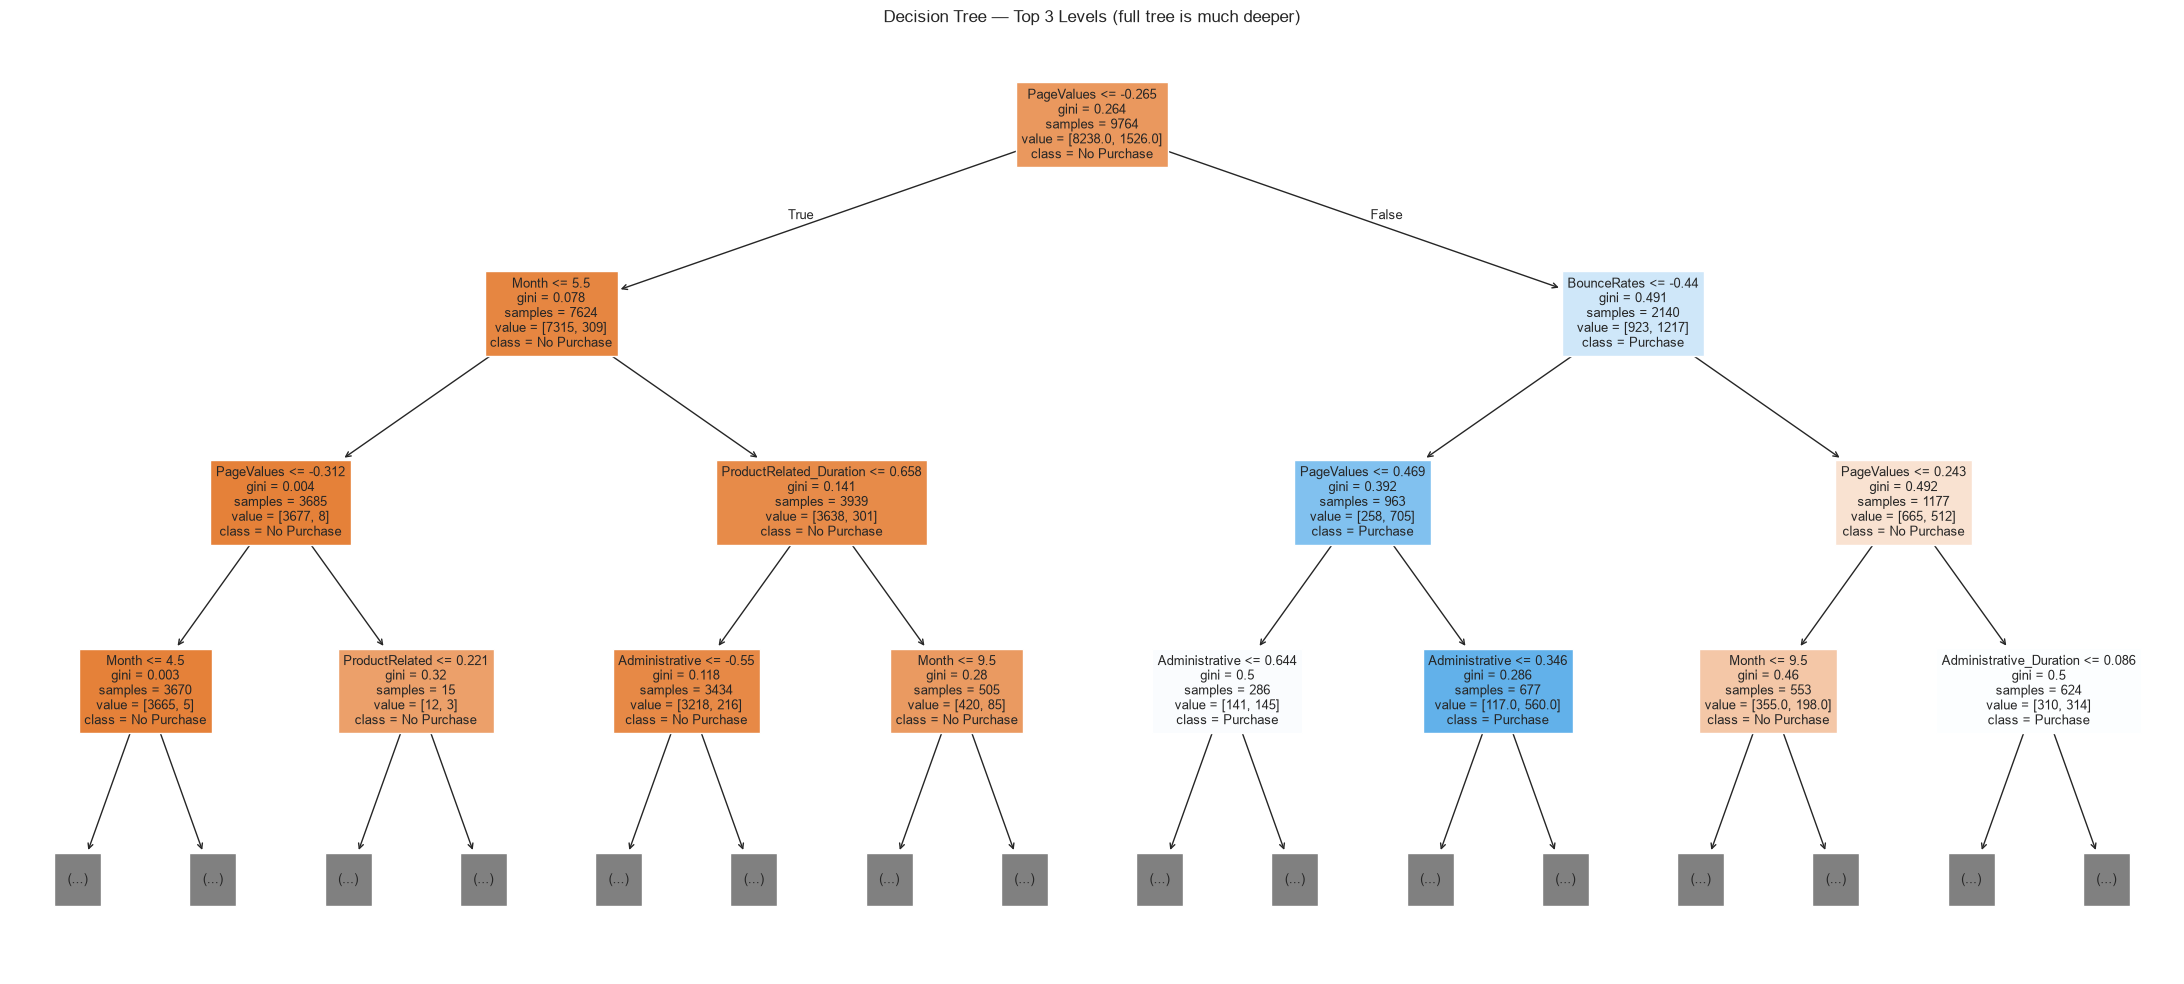

Full tree depth: 29, leaves: 810


In [26]:
plt.figure(figsize=(22, 10))
plot_tree(
    model_dt,
    feature_names=list(X_train.columns),
    class_names=["No Purchase", "Purchase"],
    filled=True,
    max_depth=3,
    fontsize=9,
)
plt.title("Decision Tree — Top 3 Levels (full tree is much deeper)")
plt.tight_layout()
plt.show()

print(f"Full tree depth: {model_dt.get_depth()}, leaves: {model_dt.get_n_leaves()}")

### 7.2 Human-readable decision rules (depth 3)

In [27]:
print(export_text(model_dt, feature_names=list(X_train.columns), max_depth=3))

|--- PageValues <= -0.27
|   |--- Month <= 5.50
|   |   |--- PageValues <= -0.31
|   |   |   |--- Month <= 4.50
|   |   |   |   |--- class: 0
|   |   |   |--- Month >  4.50
|   |   |   |   |--- truncated branch of depth 6
|   |   |--- PageValues >  -0.31
|   |   |   |--- ProductRelated <= 0.22
|   |   |   |   |--- class: 1
|   |   |   |--- ProductRelated >  0.22
|   |   |   |   |--- truncated branch of depth 2
|   |--- Month >  5.50
|   |   |--- ProductRelated_Duration <= 0.66
|   |   |   |--- Administrative <= -0.55
|   |   |   |   |--- truncated branch of depth 17
|   |   |   |--- Administrative >  -0.55
|   |   |   |   |--- truncated branch of depth 26
|   |   |--- ProductRelated_Duration >  0.66
|   |   |   |--- Month <= 9.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- Month >  9.50
|   |   |   |   |--- truncated branch of depth 15
|--- PageValues >  -0.27
|   |--- BounceRates <= -0.44
|   |   |--- PageValues <= 0.47
|   |   |   |--- Administrative <= 0.64
|  

### 7.3 Feature importances

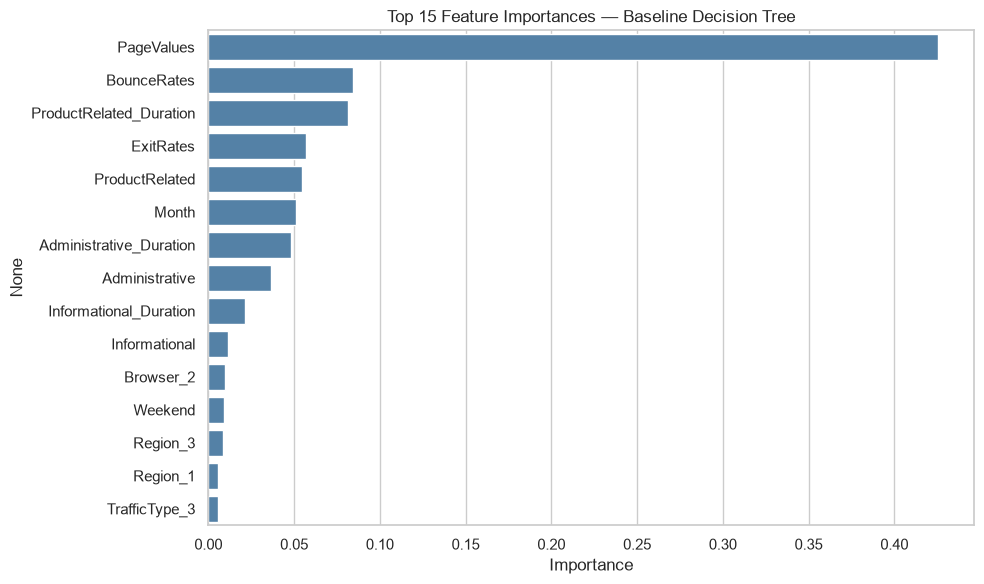

PageValues                 0.425183
BounceRates                0.084405
ProductRelated_Duration    0.081621
ExitRates                  0.057097
ProductRelated             0.054842
Month                      0.050843
Administrative_Duration    0.048026
Administrative             0.036776
Informational_Duration     0.021218
Informational              0.011269
Browser_2                  0.009956
Weekend                    0.009379
Region_3                   0.008308
Region_1                   0.005718
TrafficType_3              0.005585
dtype: float64

In [28]:
importances = pd.Series(model_dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, color="steelblue")
plt.title("Top 15 Feature Importances — Baseline Decision Tree")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances.head(15)

### 7.4 Decision boundary (PCA 2D projection)
Following the lab sheet: reduce to 2D with PCA, retrain a small tree on the 2D data and
plot the decision boundary (for intuition only — the real model uses all features).

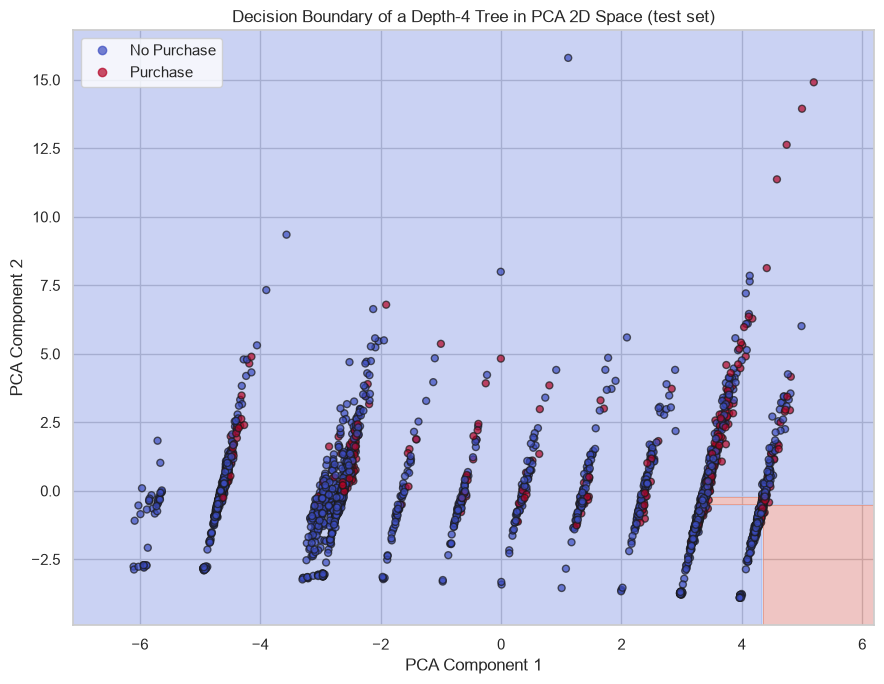

In [29]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

tree_2d = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
tree_2d.fit(X_train_pca, y_train)

x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = tree_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
scatter = plt.scatter(
    X_test_pca[:, 0], X_test_pca[:, 1], c=y_test,
    cmap="coolwarm", edgecolor="k", s=25, alpha=0.7,
)
plt.legend(handles=scatter.legend_elements()[0], labels=["No Purchase", "Purchase"])
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Decision Boundary of a Depth-4 Tree in PCA 2D Space (test set)")
plt.tight_layout()
plt.show()

## 8. Model Behaviour — Effect of `max_depth`
Testing depths 1, 3, 5, 10 and unlimited to demonstrate the **overfitting trade-off**.

In [30]:
depth_results = []
for depth in [1, 3, 5, 10, None]:
    m = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    depth_results.append({
        "max_depth": "None (unlimited)" if depth is None else depth,
        "actual_depth": m.get_depth(),
        "train_accuracy": accuracy_score(y_train, m.predict(X_train)),
        "test_accuracy": accuracy_score(y_test, p),
        "test_f1": f1_score(y_test, p),
        "test_roc_auc": roc_auc_score(y_test, proba),
    })

depth_df = pd.DataFrame(depth_results)
depth_df

,max_depth,actual_depth,train_accuracy,test_accuracy,test_f1,test_roc_auc
0,1,1,0.873822,0.877100,0.670330,0.845062
1,3,3,0.889902,0.889799,0.658196,0.909568
2,5,5,0.906596,0.895944,0.660428,0.919167
3,10,10,0.948996,0.879967,0.606711,0.840205
4,None (unlimited),29,1.000000,0.856206,0.555133,0.740996


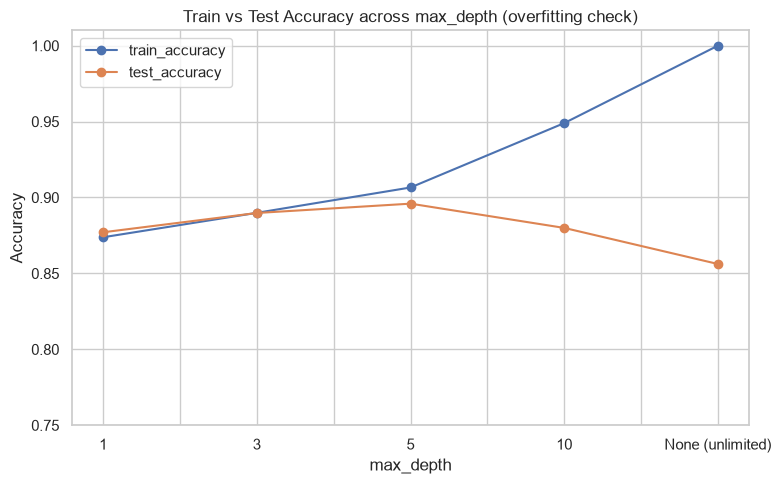

In [31]:
fig, ax = plt.subplots(figsize=(8, 5))
depth_df.plot(x="max_depth", y=["train_accuracy", "test_accuracy"], marker="o", ax=ax)
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.set_title("Train vs Test Accuracy across max_depth (overfitting check)")
ax.set_ylim(0.75, 1.01)
plt.tight_layout()
plt.show()

**Observation:** with unlimited depth the tree memorises the training data
(train accuracy ≈ 1.0) while test performance plateaus or drops — the classic overfitting
signature. A moderate `max_depth` (≈ 5–7) generalises better. Grid search below finds this
automatically.

## 9. Hyperparameter Tuning with GridSearchCV
5-fold **stratified** cross-validation over a grid covering tree size, split criterion and
class weighting (important for the imbalanced target).

In [32]:
param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    scoring="f1",          # F1 suits the imbalanced target better than accuracy
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print("Best parameters :", grid_search.best_params_)
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")

best_dt = grid_search.best_estimator_

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best parameters : {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1 score: 0.6513


## 10. Cross-Validation of the Tuned Model
Confirming stability of the best configuration with 5-fold stratified CV on the training set.

In [33]:
for metric in ["accuracy", "f1", "roc_auc"]:
    scores = cross_val_score(best_dt, X_train, y_train, cv=cv, scoring=metric, n_jobs=-1)
    print(f"{metric:>8}: {scores.mean():.4f} ± {scores.std():.4f}  (folds: {np.round(scores, 4)})")

accuracy: 0.8640 ± 0.0201  (folds: [0.8244 0.8684 0.874  0.8781 0.875 ])
      f1: 0.6513 ± 0.0274  (folds: [0.6007 0.655  0.6649 0.6827 0.6534])
 roc_auc: 0.9066 ± 0.0081  (folds: [0.9001 0.8997 0.9126 0.9197 0.9009])


## 11. Final Evaluation on the Held-Out Test Set

In [34]:
y_pred_best = best_dt.predict(X_test)
y_proba_best = best_dt.predict_proba(X_test)[:, 1]

evaluate(y_test, y_pred_best, y_proba_best, "Tuned Decision Tree")

===== Tuned Decision Tree =====
Accuracy : 0.8751
Precision: 0.5709
Recall   : 0.8115
F1 score : 0.6703
ROC AUC  : 0.9083

              precision    recall  f1-score   support

 No Purchase       0.96      0.89      0.92      2059
    Purchase       0.57      0.81      0.67       382

    accuracy                           0.88      2441
   macro avg       0.77      0.85      0.80      2441
weighted avg       0.90      0.88      0.88      2441



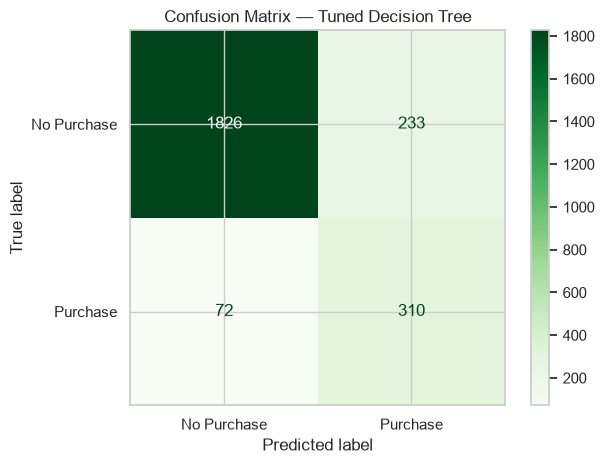

In [25]:
cm_best = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=["No Purchase", "Purchase"])
disp.plot(cmap="Greens")
plt.title("Confusion Matrix — Tuned Decision Tree")
plt.tight_layout()
plt.show()

In [35]:
# Baseline vs tuned comparison
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC AUC"],
    "Baseline": [
        accuracy_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_dt),
        roc_auc_score(y_test, y_proba_dt),
    ],
    "Tuned": [
        accuracy_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_best),
        recall_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_best),
        roc_auc_score(y_test, y_proba_best),
    ],
}).round(4)

comparison

,Metric,Baseline,Tuned
0,Accuracy,0.8562,0.8751
1,Precision,0.5381,0.5709
2,Recall,0.5733,0.8115
3,F1,0.5551,0.6703
4,ROC AUC,0.7410,0.9083


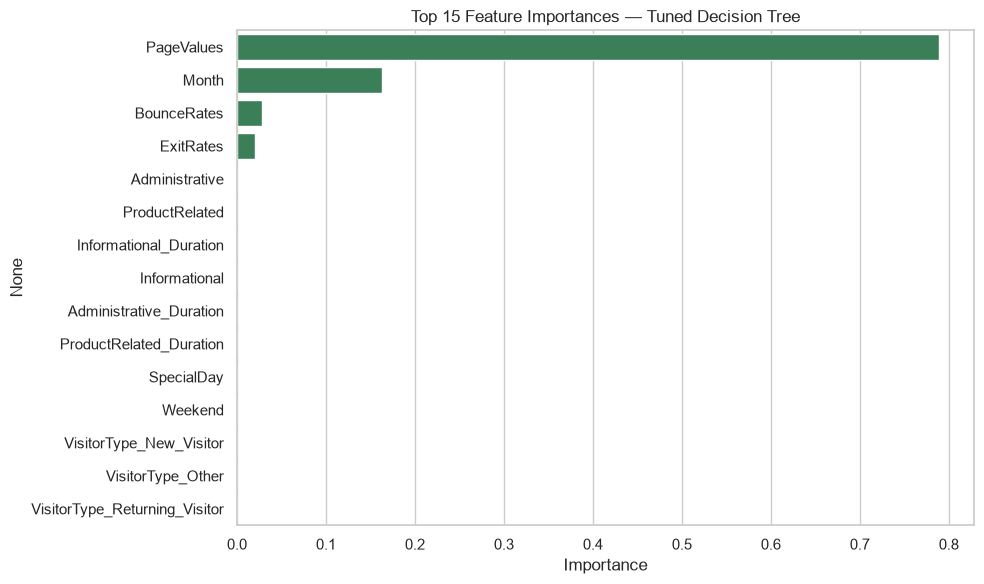

Tuned tree depth: 3 | leaves: 7


PageValues                       0.788855
Month                            0.162432
BounceRates                      0.028039
ExitRates                        0.020675
Administrative                   0.000000
ProductRelated                   0.000000
Informational_Duration           0.000000
Informational                    0.000000
Administrative_Duration          0.000000
ProductRelated_Duration          0.000000
SpecialDay                       0.000000
Weekend                          0.000000
VisitorType_New_Visitor          0.000000
VisitorType_Other                0.000000
VisitorType_Returning_Visitor    0.000000
dtype: float64

In [36]:
importances_best = pd.Series(best_dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances_best.head(15).values, y=importances_best.head(15).index, color="seagreen")
plt.title("Top 15 Feature Importances — Tuned Decision Tree")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Tuned tree depth:", best_dt.get_depth(), "| leaves:", best_dt.get_n_leaves())
importances_best.head(15)

## 12. Conclusion

### What was done
A Decision Tree classifier was built to predict purchase intention (`Revenue`) from 12,330
online shopping sessions. After encoding categorical features and an 80/20 stratified split,
a baseline (unrestricted) tree was trained, analysed across `max_depth` values, tuned with
5-fold stratified `GridSearchCV` (180 candidates), and finally evaluated on the held-out
test set.

### Key results

| Metric | Baseline (unrestricted) | Tuned (`max_depth=3`, entropy, balanced) |
|---|---|---|
| Accuracy | 0.856 | **0.875** |
| Precision (purchase) | 0.538 | **0.571** |
| Recall (purchase) | 0.573 | **0.812** |
| F1 (purchase) | 0.555 | **0.670** |
| ROC AUC | 0.741 | **0.908** |

- The **baseline tree overfits badly**: it grows to depth 29, memorises the training data
  (train accuracy = 1.0) and its test ROC AUC collapses to 0.741. The `max_depth` sweep
  shows test performance peaks around depth 5 and degrades as the tree deepens.
- Grid search selected a **shallow depth-3 tree with entropy and `class_weight='balanced'`**.
  Because the classes are imbalanced (~84.5 % vs 15.5 %), the balanced weighting lets the
  model trade a little accuracy for a large recall gain — it now correctly identifies
  **~81 % of actual buyers** versus ~57 % for the baseline.
- Cross-validation scores were stable (accuracy ≈ 0.87 ± 0.01), confirming the tuned model
  generalises and is not just lucky on one split.

### What drives purchases
`PageValues` dominates (≈ 0.79 importance) — sessions where the visitor viewed
transaction-related pages are far more likely to convert. `Month` (≈ 0.16) is second:
the data shows November (pre-holiday) and May concentrate purchases. `BounceRates` and
`ExitRates` add smaller signals: low-bounce, low-exit sessions convert more often.
